<a href="https://colab.research.google.com/github/optofficial2026/2026-OPT-1st-Homework/blob/yeeun/Week2/Week2_%EC%A1%B0%EC%98%88%EC%9D%80_CIFAR10_NN_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Neural Network on CIFAR-10 with Regularization

In this assignment, you will:
1. Build a baseline CNN for CIFAR-10 classification
2. Implement and compare regularization techniques (Dropout, BatchNorm)
3. Combine all techniques to build your best model
4. Visualize how CNNs learn (filters, feature maps, Grad-CAM)
5. Analyze and compare results

**Rules:**
- You may use PyTorch (or TensorFlow if you prefer)
- Do NOT use pretrained models
- Fill in all `# TODO` sections
- Report final test accuracy for each experiment

---

## Grading Rubric

Your grade is determined by your **Best Model** (Task 4) **final test accuracy**, evaluated in Task 6:

| Grade | Test Accuracy | Description |
|-------|--------------|-------------|
| **A+** | >= 85% | Excellent — strong architecture with well-tuned regularization |
| **A** | >= 82% | Great — good combination of techniques |
| **B+** | >= 79% | Good effort — room for optimization |
| **B** | >= 76% | Decent — used some techniques effectively |
| **C** | >= 70% | Minimal effort — near baseline performance |
| **F** | < 70% | Needs more work |

**Per-task minimum thresholds** (must pass all to receive full credit):
- Task 1 (Baseline): >= 65% — confirms a working CNN
- Task 2 (Dropout): >= 65%
- Task 3 (BatchNorm): >= 70%
- Task 4 (Best Model): >= 70%
- Task 5 (Visualization): Complete all visualizations and answer questions
- Task 6 (Analysis): Answer all questions thoughtfully

## 0. Setup

//CIFAR-10 이미지는 32x32x3 크기

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 1. Data Loading

CIFAR-10: 60,000 32x32 color images in 10 classes (50k train, 10k test).

We split the training set into **train (45k)** and **validation (5k)** so that we tune hyperparameters on the validation set and only evaluate on the test set at the very end.

In [3]:
# Basic transform (no augmentation yet)
#Task4(best model)에서 성능을 높일 때 이 코드에대한 이해 필요
#이따가 data augmentation(좌우반전 등등)을 할거임
#train set(trainloader): 모델이 학습하는 데이터
#Validation set(valloader): 중간 점검하는 데이터, 이걸 보고 값을 수정함, 여기서 너무 맞추면 overfiting 발생하는듯
#Test set(testloader): 최종 시험, 딱 한 번 하는 거(Task6)

#transform_basic: 사진을 컴퓨터가 이해하기 쉬운 숫자 뭉치(tensor)로 바꾸고
#평균값을 맞춰서(normalize) 공부하기 좋게 다듬는 도구
transform_basic = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# Full training set (we will split into train + val)
#full_trainset: 인터넷에서 CIFAR-10 사진 5만장 다운로드
full_trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_basic)

# Split: 45k train, 5k validation
#random_split: 45000장은 학습(train)용 5000장은 검토용(validation)
trainset, valset = torch.utils.data.random_split(full_trainset, [45000, 5000],
                                                  generator=torch.Generator().manual_seed(42))
#DataLoader: 사진 한 장씩 안 주고 128장씩 묶어서(batch_size) 모델에게 던져주는 "배달원 역할"
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
valloader = torch.utils.data.DataLoader(valset, batch_size=128, shuffle=False, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_basic)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:14<00:00, 11.8MB/s]


## 2. Training & Evaluation Helpers

> **Note:** Dropout and BatchNorm behave differently during training vs. evaluation. The `train()` function calls `model.train()` and `evaluate()` calls `model.eval()` — this is critical for correct results.

In [5]:
#모델을 학습시키고 평가할 때 반복해서 사용할 함수 작성
#Train함수
#model.train(): 지금부터 학습 시작할거라고 선언(Dropout이나 BatchNorm이 학습 모드로 작동하게 됨)
#optimizer.sero_grad(): 이전 문제 풀었던 기억(기울기)을 지우고 새 문제를 풀 준비를 함
#loss.backword(): 정답과 비교해서 얼마나 틀렸는지 계산하고 그 오차를 뒤로 전달(역전파) 함
#optimizer.step(): 오차를 바탕으로 모델의 머릿속(가중치)를 조금씩 수정함

#evaluate 함수(시험보기)
#model.eval(): 이제 학습 끝났고 시험볼거야 라고 선언(dropout같은 방해 요소 끔)
#torch.no_grad(): 지금은 시험보는 중이니까 학습하지 말라고 명령


def train(model, loader, criterion, optimizer, epochs=20):
    """Train the model. Returns lists of (train_loss, train_acc) per epoch."""
    model.train()
    history = {'loss': [], 'acc': []}
    for epoch in range(epochs):
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
        epoch_loss = running_loss / total
        epoch_acc = correct / total
        history['loss'].append(epoch_loss)
        history['acc'].append(epoch_acc)
        print(f'Epoch {epoch+1:2d}/{epochs} \u2014 Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}')
    return history


def evaluate(model, loader):
    """Evaluate the model on a dataset. Returns (loss, accuracy)."""
    model.eval()
    criterion = nn.CrossEntropyLoss()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total

---
## Task 1: Baseline CNN (No Regularization)

Build a simple CNN. Suggested architecture:
- 2~3 Conv blocks (Conv2d -> ReLU -> MaxPool2d)
- 1~2 Fully connected layers
- No dropout, no batch norm, no weight decay

In [9]:
#dropout, BatchNorm 없는 CNN의 기준점 만드는 단계
#nn.Conv2d: 이미지의 특징(선, 색, 패턴)을 잡아내는 돋보기 역할
#nn.ReLU: 계산 결과에서 -값은 무시 +값만 살리는 필터링 역할
#nn.MaxPool2d: 이미지에서 가장 강한 특징만 남기고 크기를 줄여 핵심만 요약
#torch.flatten: 2d 이미지를 한 줄(1D)로 길게 펴서, 마지막 분류기가 읽을 수 있게 만듦

#채널수, FC 레이어 크기, 학습률 등을 조작

class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        #1. 특징 추출부
        self.features = nn.Sequential(
          #block1: 32X32 -> 16X16 이미지 크기 반으로 줄임
          # 3X3 필터 32개 사용(입력 3채널 -> 출력 32채널)
          nn.Conv2d(3, 32, kernel_size=3, padding=1),
          nn.ReLU(),
          nn.MaxPool2d(2, 2),
          #block2:16X16 -> 8X8
          #32 채널 -> 64채널
          nn.Conv2d(32, 64, kernel_size=3, padding=1),
          nn.ReLU(),
          nn.MaxPool2d(2, 2),
          #block1: 8X8 ->4X4
          #64채널 128채널
          nn.Conv2d(64, 128, kernel_size=3, padding=1),
          nn.ReLU(),
          nn.MaxPool2d(2, 2)
        )
        #2. 분류부(Fully connected layers)
        #마지막 출력 크기는 128채널 *4*4 크기
        self.fc_layers = nn.Sequential(
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256,10) #최종 클래스 10개(비행기, 자동차 등)
        )

    def forward(self, x):
        x = self.features(x) #특징 추출 통과
        x = torch.flatten(x, 1) #1차원으로 펴주기(linear layer를 위해)
        x = self.fc_layers(x) #최종 분류결과 도출
        return x


baseline = BaselineCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

hist_baseline = train(baseline, trainloader, criterion, optimizer, epochs=20)
val_loss, val_acc = evaluate(baseline, valloader)
print(f'\n[Baseline] Val Accuracy: {val_acc:.4f}')

#결과: [Baseline] Val Accuracy: 0.7674

Epoch  1/20 — Loss: 1.4082, Acc: 0.4887
Epoch  2/20 — Loss: 0.9819, Acc: 0.6543
Epoch  3/20 — Loss: 0.7917, Acc: 0.7240
Epoch  4/20 — Loss: 0.6593, Acc: 0.7700
Epoch  5/20 — Loss: 0.5622, Acc: 0.8031
Epoch  6/20 — Loss: 0.4694, Acc: 0.8375
Epoch  7/20 — Loss: 0.3859, Acc: 0.8654
Epoch  8/20 — Loss: 0.3000, Acc: 0.8938
Epoch  9/20 — Loss: 0.2396, Acc: 0.9150
Epoch 10/20 — Loss: 0.1759, Acc: 0.9375
Epoch 11/20 — Loss: 0.1330, Acc: 0.9520
Epoch 12/20 — Loss: 0.1050, Acc: 0.9628
Epoch 13/20 — Loss: 0.0948, Acc: 0.9673
Epoch 14/20 — Loss: 0.0842, Acc: 0.9708
Epoch 15/20 — Loss: 0.0661, Acc: 0.9770
Epoch 16/20 — Loss: 0.0601, Acc: 0.9788
Epoch 17/20 — Loss: 0.0640, Acc: 0.9772
Epoch 18/20 — Loss: 0.0588, Acc: 0.9800
Epoch 19/20 — Loss: 0.0644, Acc: 0.9780
Epoch 20/20 — Loss: 0.0490, Acc: 0.9827

[Baseline] Val Accuracy: 0.7674


---
## Task 2: Dropout Regularization

Copy your baseline and add **Dropout** layers. Experiment with dropout rates (e.g., 0.25, 0.5).

> **Tip:** Start with a lower rate like 0.25. High dropout (0.5) on small networks with few epochs can hurt training convergence — this is itself a useful observation.

In [13]:
#dropout 실습
#nn.dropout 활용
class DropoutCNN(nn.Module):
  #dropout_rate 추가, 얼마나 끄고 공부할지 결정, 0.25는 25%
    def __init__(self, drop_rate=0.38):
        super().__init__()
        #1. 특징 추출부(BaseLine + Dropout)
        self.features = nn.Sequential(
          nn.Conv2d(3, 32, kernel_size=3, padding=1),
          nn.ReLU(),
          nn.MaxPool2d(2, 2),
          #새로 추가
          nn.Dropout2d(p=drop_rate),

          nn.Conv2d(32, 64, kernel_size=3, padding=1),
          nn.ReLU(),
          nn.MaxPool2d(2, 2),
          nn.Dropout2d(p=drop_rate),

          nn.Conv2d(64, 128, kernel_size=3, padding=1),
          nn.ReLU(),
          nn.MaxPool2d(2, 2),
          nn.Dropout2d(p=drop_rate)
        )
        #2. 분류부(Linear 사이에도 dropout 추가)
        self.fc_layers = nn.Sequential(
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout2d(p=drop_rate),
            nn.Linear(256,10)
        )

    def forward(self, x):
        x = self.features(x) #특징 추출 통과
        x = torch.flatten(x, 1) #1차원으로 펴주기(linear layer를 위해)
        x = self.fc_layers(x) #최종 분류결과 도출
        return x



dropout_model = DropoutCNN(drop_rate=0.25).to(device)
optimizer = optim.Adam(dropout_model.parameters(), lr=1e-3)

hist_dropout = train(dropout_model, trainloader, criterion, optimizer, epochs=20)
val_loss, val_acc = evaluate(dropout_model, valloader)
print(f'\n[Dropout] Val Accuracy: {val_acc:.4f}')

#[Dropout] Val Accuracy: 0.7722 -> 25%일때
#[Dropout] Val Accuracy: 0.7598 -> 50%
#[Dropout] Val Accuracy: 0.7720 -> 38%

Epoch  1/20 — Loss: 1.6434, Acc: 0.4072
Epoch  2/20 — Loss: 1.2959, Acc: 0.5382
Epoch  3/20 — Loss: 1.1475, Acc: 0.5950
Epoch  4/20 — Loss: 1.0399, Acc: 0.6341
Epoch  5/20 — Loss: 0.9758, Acc: 0.6572
Epoch  6/20 — Loss: 0.9200, Acc: 0.6770
Epoch  7/20 — Loss: 0.8800, Acc: 0.6909
Epoch  8/20 — Loss: 0.8334, Acc: 0.7053
Epoch  9/20 — Loss: 0.8065, Acc: 0.7177
Epoch 10/20 — Loss: 0.7761, Acc: 0.7294
Epoch 11/20 — Loss: 0.7571, Acc: 0.7342
Epoch 12/20 — Loss: 0.7308, Acc: 0.7426
Epoch 13/20 — Loss: 0.7149, Acc: 0.7494
Epoch 14/20 — Loss: 0.6952, Acc: 0.7541
Epoch 15/20 — Loss: 0.6777, Acc: 0.7611
Epoch 16/20 — Loss: 0.6600, Acc: 0.7661
Epoch 17/20 — Loss: 0.6407, Acc: 0.7745
Epoch 18/20 — Loss: 0.6332, Acc: 0.7764
Epoch 19/20 — Loss: 0.6209, Acc: 0.7814
Epoch 20/20 — Loss: 0.6111, Acc: 0.7857

[Dropout] Val Accuracy: 0.7720


---
## Task 3: Batch Normalization

Copy your baseline and add **BatchNorm2d** (after conv layers) and/or **BatchNorm1d** (after FC layers).

In [15]:
#BatchNormalization: 계산 결과가 너무 들쭉날쭉하지 않게 맞춰주기
#nn.BatchNorm2d(32)
class BatchNormCNN(nn.Module):
    def __init__(self):
        super().__init__()
         #1. 특징 추출부(Conv -> BatchNorm -> ReLU)
        self.features = nn.Sequential(
            #nn.BatchNorm(): 괄호안에는 출력 채널 숫자
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
            )
        #2. 분류부(Linear -> BatchNorm -> ReLU)
        self.fc_layers = nn.Sequential(
            nn.Linear(128 * 4 * 4, 256),
            nn.BatchNorm1d(256), #1d로 변경
            nn.ReLU(),
            nn.Linear(256,10)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        #이전까지는 이미지 형태라 2d를 썼지만 flatten 이후에는 그냥 linear한 형태
        #그래서 1d batchnorm써야함
        x = self.fc_layers(x)
        return x


bn_model = BatchNormCNN().to(device)
optimizer = optim.Adam(bn_model.parameters(), lr=1e-3)

hist_bn = train(bn_model, trainloader, criterion, optimizer, epochs=20)
val_loss, val_acc = evaluate(bn_model, valloader)
print(f'\n[BatchNorm] Val Accuracy: {val_acc:.4f}')

#[BatchNorm] Val Accuracy: 0.7596
#task 1,2보다 월등하게 좋지는 않음, 기준점은 통과
#task1: 76 task2: 77 task3: 75

Epoch  1/20 — Loss: 1.0894, Acc: 0.6111
Epoch  2/20 — Loss: 0.7404, Acc: 0.7412
Epoch  3/20 — Loss: 0.5769, Acc: 0.8001
Epoch  4/20 — Loss: 0.4482, Acc: 0.8461
Epoch  5/20 — Loss: 0.3436, Acc: 0.8820
Epoch  6/20 — Loss: 0.2491, Acc: 0.9160
Epoch  7/20 — Loss: 0.1831, Acc: 0.9407
Epoch  8/20 — Loss: 0.1275, Acc: 0.9604
Epoch  9/20 — Loss: 0.0904, Acc: 0.9736
Epoch 10/20 — Loss: 0.0769, Acc: 0.9778
Epoch 11/20 — Loss: 0.0705, Acc: 0.9780
Epoch 12/20 — Loss: 0.0654, Acc: 0.9798
Epoch 13/20 — Loss: 0.0488, Acc: 0.9854
Epoch 14/20 — Loss: 0.0451, Acc: 0.9864
Epoch 15/20 — Loss: 0.0468, Acc: 0.9850
Epoch 16/20 — Loss: 0.0503, Acc: 0.9838
Epoch 17/20 — Loss: 0.0524, Acc: 0.9824
Epoch 18/20 — Loss: 0.0380, Acc: 0.9883
Epoch 19/20 — Loss: 0.0206, Acc: 0.9949
Epoch 20/20 — Loss: 0.0217, Acc: 0.9938

[BatchNorm] Val Accuracy: 0.7596


---
## Task 4: Best Model — Combine Everything

Now combine the techniques that worked best. Try to **maximize validation accuracy**. (Final test accuracy is evaluated once in Task 6.)

You may use any combination of:
- BatchNorm, Dropout
- Weight decay (`weight_decay` parameter in optimizer)
- Data augmentation (e.g., `RandomHorizontalFlip`, `RandomCrop`, `ColorJitter`)
- Deeper/wider architectures
- Learning rate scheduling (`optim.lr_scheduler`)
- More epochs
- Different optimizers (SGD + momentum)

In [17]:
# (Optional) Define an augmented transform for better training
transform_aug = transforms.Compose([
    #50% 확률로 좌우반전
    transforms.RandomHorizontalFlip(),
    #살짝 위치 옮겨서 자르기
    transforms.RandomCrop(32, padding=4),
    #color도 변화주기
    transforms.ColorJitter(brightness=0.2, contrast=0.2),

    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

full_trainset_aug = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_aug)
trainset_aug, _ = torch.utils.data.random_split(full_trainset_aug, [45000, 5000],
                                                 generator=torch.Generator().manual_seed(42))
trainloader_aug = torch.utils.data.DataLoader(trainset_aug, batch_size=128, shuffle=True, num_workers=2)

#3-> 64 채널: 색깔, edge등 기본 특징
#64 -> 128 더 복잡한 패턴(귀, 눈, 바퀴 등)
#128-> 256 더 고수준 특징(동물 형태, 자동차 형태 등)
#채널은 커지는데 이미지 크기는 줄어듦
#작게 압축해서 더 많은 특징을 담자
class BestCNN(nn.Module):
    def __init__(self):
      super().__init__()
      #1. 특징 추출부
      self.features = nn.Sequential(
          # Block 1
          #conv로 1차 특징 추출
          #conv, BN 한 세트로 보통 사용
          nn.Conv2d(3, 64, kernel_size=3, padding=1),
          nn.BatchNorm2d(64),
          nn.ReLU(),
          #conv로 결과값 다시 가공
          nn.Conv2d(64, 64, kernel_size=3, padding=1),
          nn.BatchNorm2d(64),
          nn.ReLU(),
          nn.MaxPool2d(2, 2),
          nn.Dropout(0.2), # Dropout으로 과적합 방지

          # Block 2
          nn.Conv2d(64, 128, kernel_size=3, padding=1),
          nn.BatchNorm2d(128),
          nn.ReLU(),
          nn.Conv2d(128, 128, kernel_size=3, padding=1),
          nn.BatchNorm2d(128),
          nn.ReLU(),
          nn.MaxPool2d(2, 2),
          nn.Dropout(0.3),

          # Block 3
          nn.Conv2d(128, 256, kernel_size=3, padding=1),
          nn.BatchNorm2d(256),
          nn.ReLU(),
          nn.MaxPool2d(2, 2),
          nn.Dropout(0.4)
          )
      #2. 분류부
      self.fc_layers = nn.Sequential(
          nn.Linear(256 * 4 * 4, 512),
          nn.BatchNorm1d(512),
          nn.ReLU(),
          nn.Linear(512,10)
      )
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.fc_layers(x)
        return x


best_model = BestCNN().to(device)
# Weight Decay(가중치 감쇠)를 추가해서 모델이 너무 복잡해지지 않게 합니다.
optimizer = optim.Adam(best_model.parameters(), lr=1e-3, weight_decay=1e-4)

# (선택사항) 학습 도중에 공부 속도(LR)를 줄여주는 도구
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.1)

# You may use trainloader (no augmentation) or trainloader_aug (with augmentation)
hist_best = train(best_model, trainloader_aug, criterion, optimizer, epochs=30)
val_loss, val_acc = evaluate(best_model, valloader)

#scheduler 위한 코드 추가
for epoch in range(30):
    train(best_model, trainloader_aug, criterion, optimizer, epochs=1)
    scheduler.step()
print(f'\n[Best Model] Val Accuracy: {val_acc:.4f}')

#[Best Model] Val Accuracy: 0.8864-> 스케줄러 썼을 때
#스케줄러: 처음에는 크게 크게 학습하고 점점 세밀하게 학습하도록 조정해주는 거
#[Best Model] Val Accuracy: 0.8852

Epoch  1/30 — Loss: 1.3975, Acc: 0.4899
Epoch  2/30 — Loss: 0.9723, Acc: 0.6533
Epoch  3/30 — Loss: 0.8315, Acc: 0.7041
Epoch  4/30 — Loss: 0.7522, Acc: 0.7338
Epoch  5/30 — Loss: 0.6906, Acc: 0.7576
Epoch  6/30 — Loss: 0.6470, Acc: 0.7724
Epoch  7/30 — Loss: 0.6075, Acc: 0.7876
Epoch  8/30 — Loss: 0.5819, Acc: 0.7978
Epoch  9/30 — Loss: 0.5562, Acc: 0.8071
Epoch 10/30 — Loss: 0.5369, Acc: 0.8118
Epoch 11/30 — Loss: 0.5130, Acc: 0.8196
Epoch 12/30 — Loss: 0.5014, Acc: 0.8273
Epoch 13/30 — Loss: 0.4772, Acc: 0.8347
Epoch 14/30 — Loss: 0.4615, Acc: 0.8393
Epoch 15/30 — Loss: 0.4499, Acc: 0.8444
Epoch 16/30 — Loss: 0.4440, Acc: 0.8463
Epoch 17/30 — Loss: 0.4341, Acc: 0.8505
Epoch 18/30 — Loss: 0.4169, Acc: 0.8550
Epoch 19/30 — Loss: 0.4105, Acc: 0.8568
Epoch 20/30 — Loss: 0.4021, Acc: 0.8605
Epoch 21/30 — Loss: 0.3911, Acc: 0.8627
Epoch 22/30 — Loss: 0.3924, Acc: 0.8619
Epoch 23/30 — Loss: 0.3823, Acc: 0.8668
Epoch 24/30 — Loss: 0.3769, Acc: 0.8690
Epoch 25/30 — Loss: 0.3709, Acc: 0.8705


---
## Task 5: Visualizing How CNNs Work

Understanding what happens inside a CNN is crucial for building intuition. In this section you will:

1. **Visualize first-layer convolutional filters** — what low-level patterns does the network learn?
2. **Visualize feature maps (activations)** — how does each layer transform the input image?
3. **Grad-CAM heatmaps** — where does the model "look" when making a prediction?
4. **Compare Baseline vs BatchNorm** — how does BatchNorm affect what the CNN learns?

The helper functions are provided below. Your job is to **call them on your trained models**, observe the outputs, and **answer the questions**.

In [18]:
# ===== Visualization Helpers (provided — do not modify) =====

def show_original_image(image, label=None):
    """Display a single CIFAR-10 image (un-normalized)."""
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
    img = image.cpu() * std + mean
    img = img.clamp(0, 1)
    plt.figure(figsize=(2, 2))
    plt.imshow(img.permute(1, 2, 0).numpy())
    if label is not None:
        plt.title(f"Label: {classes[label]}")
    plt.axis('off')
    plt.show()


def _get_conv_layers(model):
    """Return an ordered list of (name, Conv2d module) from the model."""
    convs = []
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            convs.append((name, module))
    return convs


def visualize_filters(model, title="First Conv Layer Filters"):
    """Visualize the filters of the first Conv2d layer."""
    conv_layers = _get_conv_layers(model)
    if not conv_layers:
        print("No Conv2d layers found in model.")
        return
    first_conv = conv_layers[0][1]
    filters = first_conv.weight.data.cpu().clone()
    n = min(filters.shape[0], 16)
    fig, axes = plt.subplots(2, 8, figsize=(14, 3.5))
    for i, ax in enumerate(axes.flat):
        if i < n:
            f = filters[i]
            f = (f - f.min()) / (f.max() - f.min())
            ax.imshow(f.permute(1, 2, 0).numpy())
        ax.axis('off')
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def visualize_feature_maps(model, image, title="Feature Maps"):
    """Visualize feature maps at each Conv2d layer for a single image."""
    model.eval()
    conv_layers = _get_conv_layers(model)
    if not conv_layers:
        print("No Conv2d layers found in model.")
        return

    # Register forward hooks on all conv layers
    activations = {}
    hooks = []
    for name, layer in conv_layers:
        def hook_fn(module, input, output, name=name):
            activations[name] = output.detach().cpu().squeeze(0)
        hooks.append(layer.register_forward_hook(hook_fn))

    # Forward pass
    with torch.no_grad():
        x = image.unsqueeze(0).to(device)
        model(x)

    # Remove hooks
    for h in hooks:
        h.remove()

    # Plot
    for i, (name, _) in enumerate(conv_layers):
        act = activations[name]
        n_ch = min(act.shape[0], 8)
        fig, axes = plt.subplots(1, n_ch, figsize=(n_ch * 2, 2))
        if n_ch == 1:
            axes = [axes]
        for j in range(n_ch):
            axes[j].imshow(act[j], cmap='viridis')
            axes[j].axis('off')
        label = f"Conv {i+1} (ch={act.shape[0]}, {act.shape[1]}x{act.shape[2]})"
        plt.suptitle(f"{title} \u2014 {label}", fontsize=12)
        plt.tight_layout()
        plt.show()


def grad_cam(model, image, target_class=None):
    """Compute Grad-CAM heatmap for the last Conv2d layer."""
    import torch.nn.functional as F
    model.eval()

    conv_layers = _get_conv_layers(model)
    if not conv_layers:
        raise ValueError("No Conv2d layers found in model.")
    last_conv = conv_layers[-1][1]

    gradients, activations_list = [], []

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    def forward_hook(module, input, output):
        activations_list.append(output)

    handle_f = last_conv.register_forward_hook(forward_hook)
    handle_b = last_conv.register_full_backward_hook(backward_hook)

    input_tensor = image.unsqueeze(0).to(device).requires_grad_(True)
    output = model(input_tensor)
    if target_class is None:
        target_class = output.argmax(1).item()
    model.zero_grad()
    output[0, target_class].backward()

    grads = gradients[0].cpu().data.numpy()[0]
    acts = activations_list[0].cpu().data.numpy()[0]
    weights = np.mean(grads, axis=(1, 2))
    cam = np.sum(weights[:, None, None] * acts, axis=0)
    cam = np.maximum(cam, 0)
    cam = cam / (cam.max() + 1e-8)

    cam_tensor = torch.from_numpy(cam).unsqueeze(0).unsqueeze(0).float()
    cam_resized = F.interpolate(cam_tensor, size=(32, 32), mode='bilinear', align_corners=False)
    cam_resized = cam_resized.squeeze().numpy()

    handle_f.remove()
    handle_b.remove()
    return cam_resized, target_class


def show_grad_cam(model, image, label=None, title="Grad-CAM"):
    """Display Grad-CAM heatmap overlaid on the original image."""
    cam, pred_class = grad_cam(model, image)
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
    img = (image.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    axes[0].imshow(img)
    axes[0].set_title("Original")
    axes[0].axis('off')
    axes[1].imshow(cam, cmap='jet')
    axes[1].set_title("Grad-CAM")
    axes[1].axis('off')
    axes[2].imshow(img)
    axes[2].imshow(cam, cmap='jet', alpha=0.5)
    axes[2].set_title(f"Overlay (pred: {classes[pred_class]})")
    axes[2].axis('off')
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

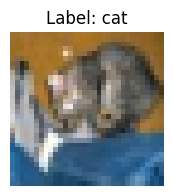

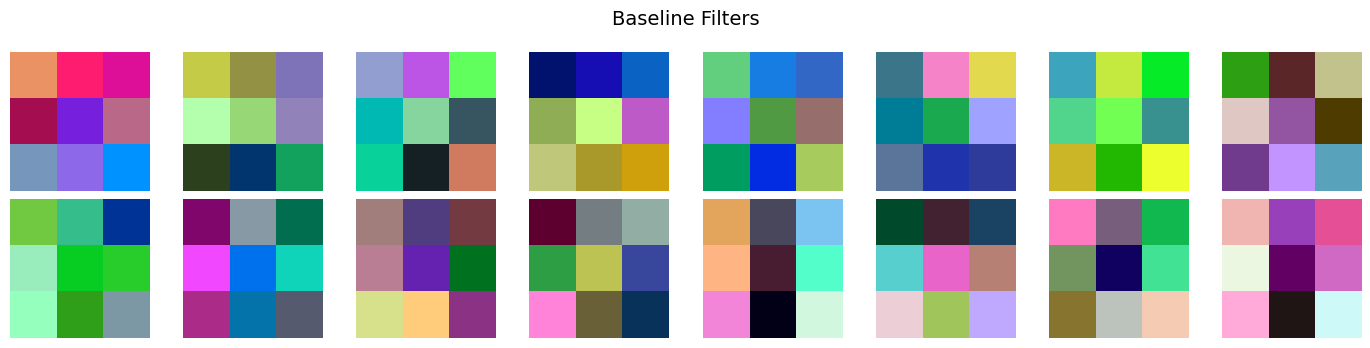

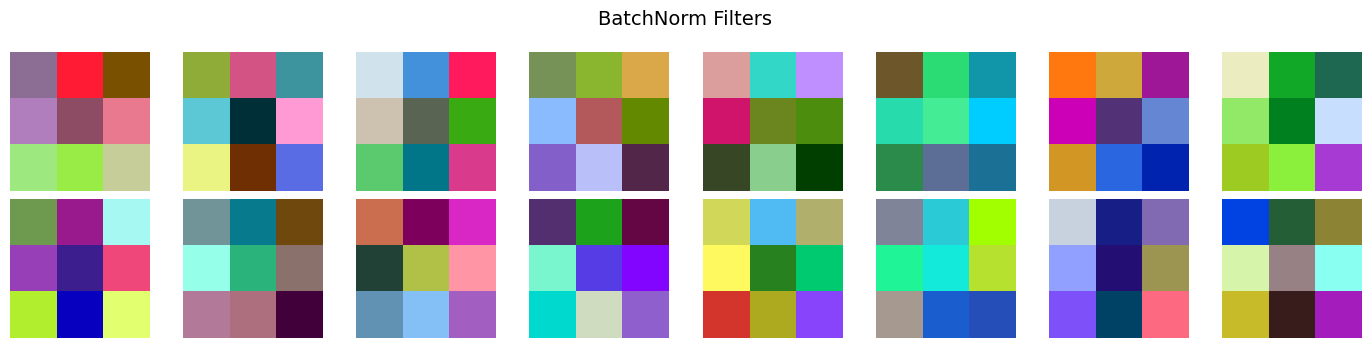

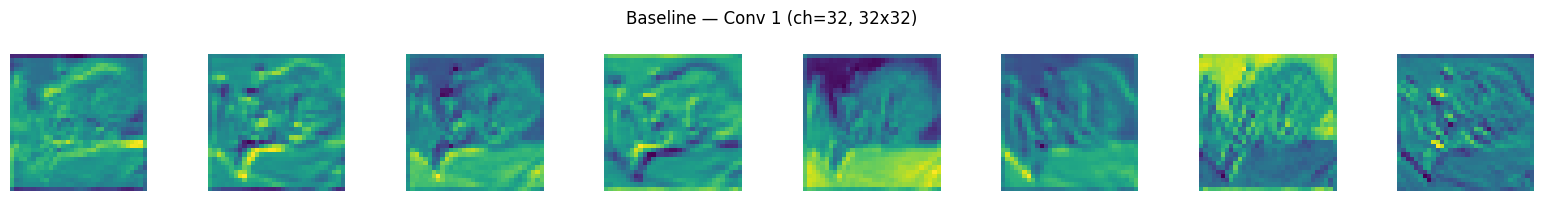

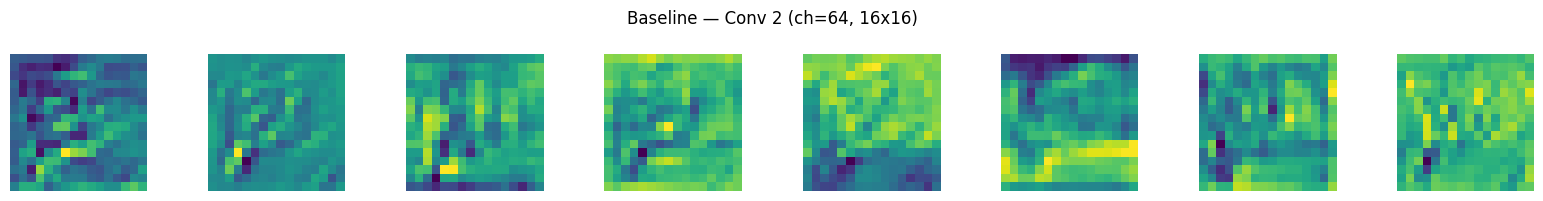

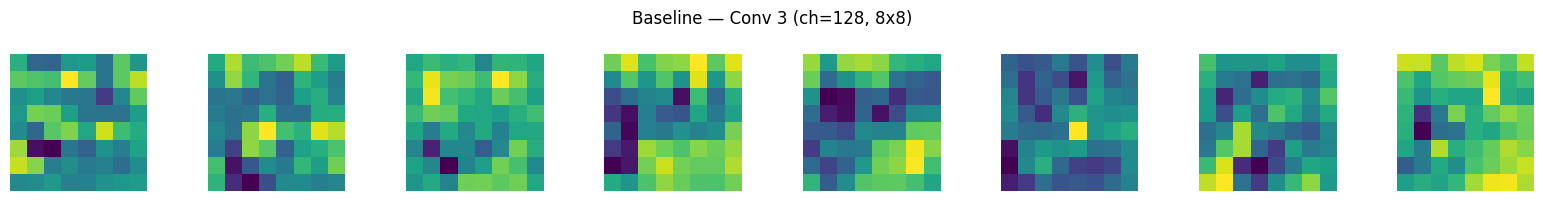

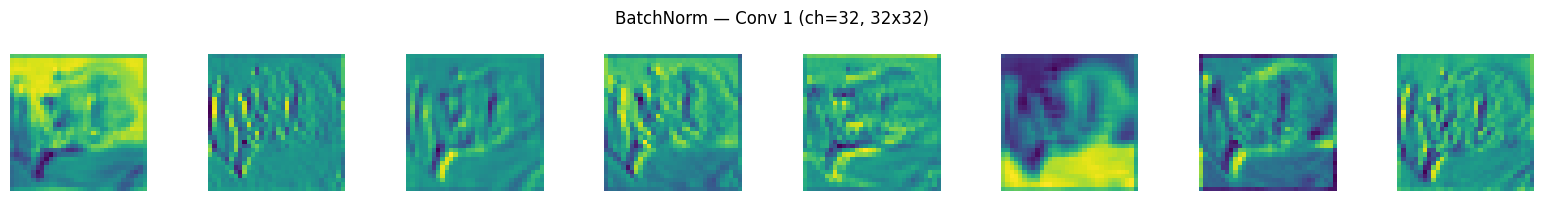

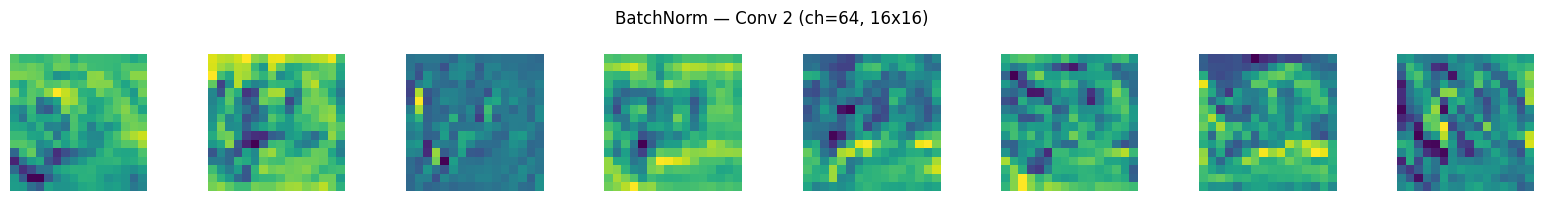

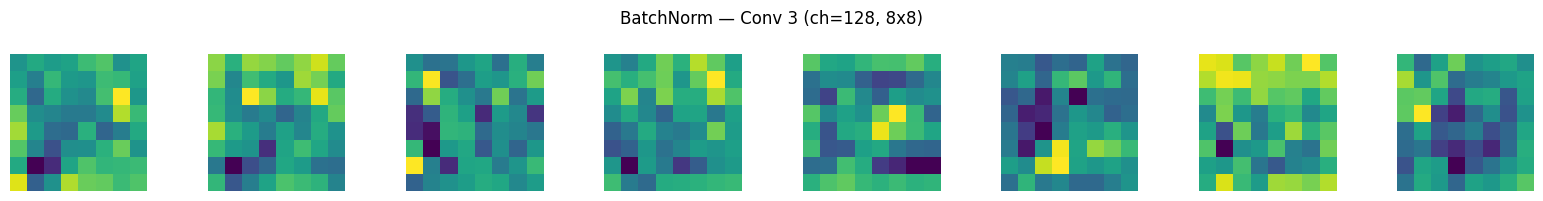

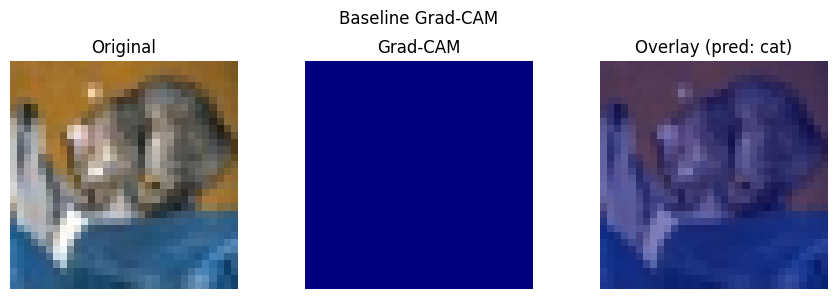

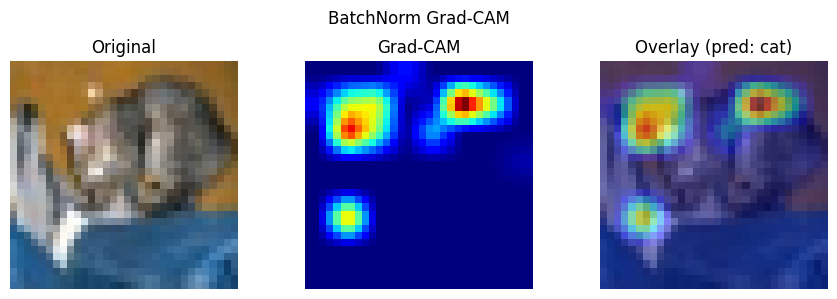


--- Image index: 10 ---


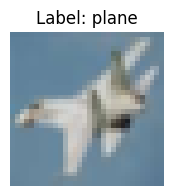

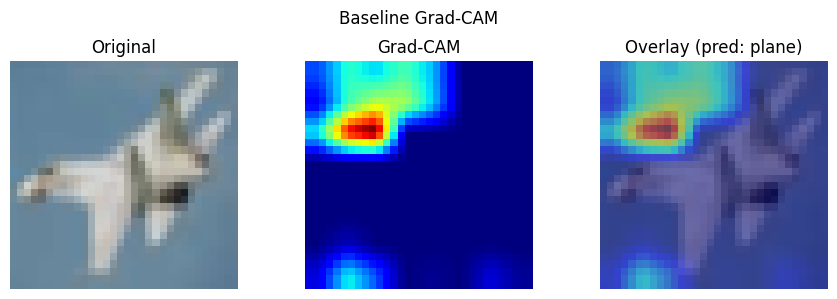

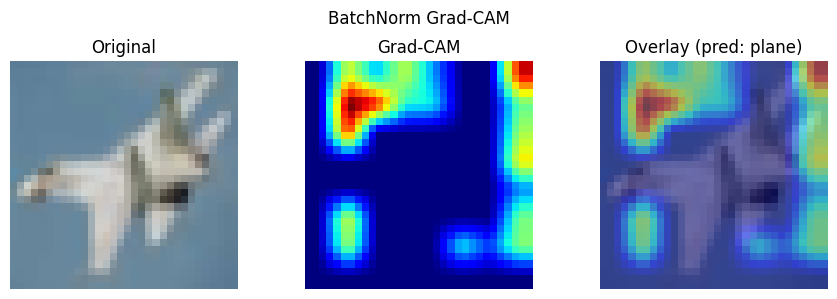


--- Image index: 100 ---


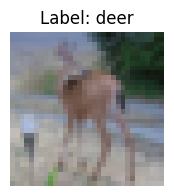

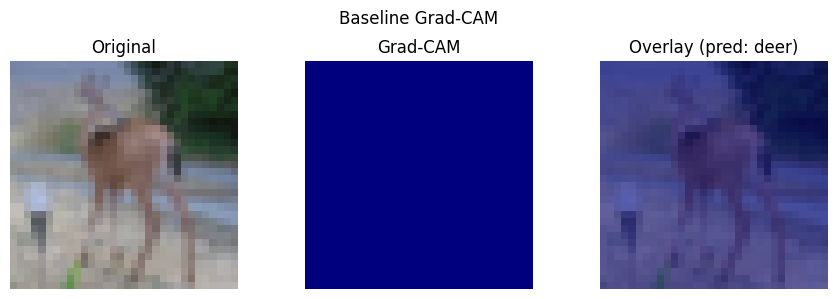

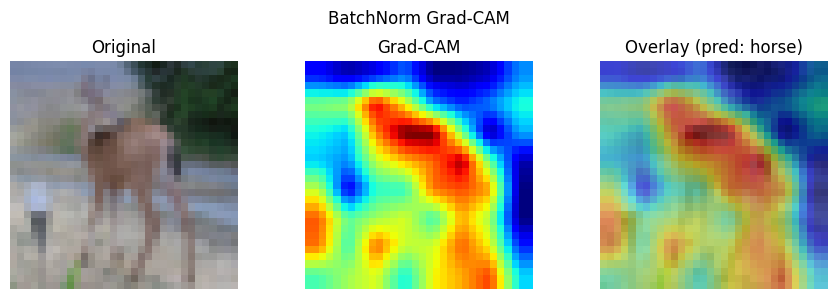


--- Image index: 500 ---


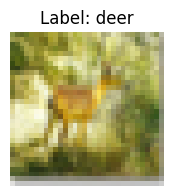

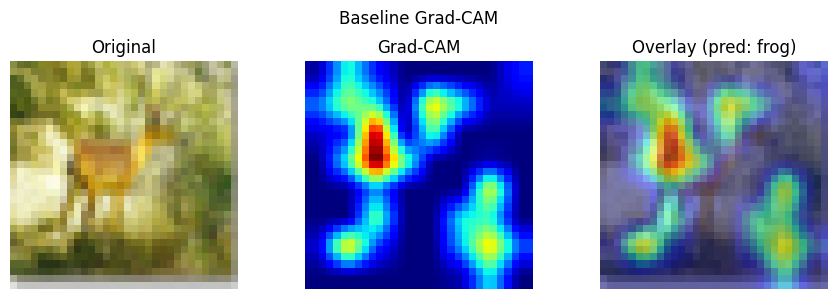

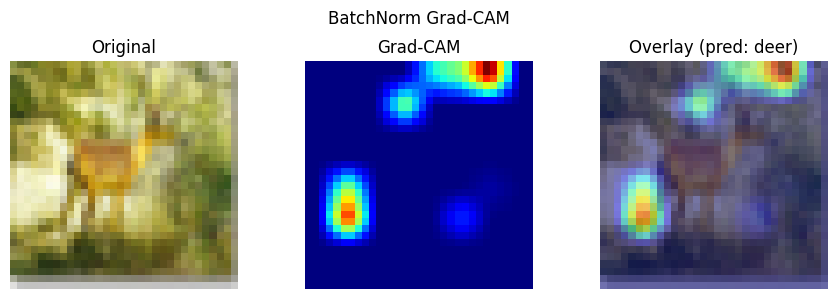

In [23]:
# --- Pick a sample image for visualization ---
sample_image, sample_label = testset[0]
show_original_image(sample_image, sample_label)

# TODO: Visualize first-layer filters for Baseline and BatchNorm models
visualize_filters(baseline, title="Baseline Filters")
visualize_filters(bn_model, title="BatchNorm Filters")


# TODO: Visualize feature maps for both models on the sample image
visualize_feature_maps(baseline, sample_image, title="Baseline")
visualize_feature_maps(bn_model, sample_image, title="BatchNorm")


# TODO: Show Grad-CAM heatmaps for both models
show_grad_cam(baseline, sample_image, title="Baseline Grad-CAM")
show_grad_cam(bn_model, sample_image, title="BatchNorm Grad-CAM")


# TODO: Try at least 3 different images from different classes and compare.
#       Do the models focus on different regions?
# (위 TODO 주석들 다 실행한 다음)

indices = [10, 100, 500]

for idx in indices:
    img, label = testset[idx]

    print(f"\n--- Image index: {idx} ---")
    show_original_image(img, label)

    show_grad_cam(baseline, img, title="Baseline Grad-CAM")
    show_grad_cam(bn_model, img, title="BatchNorm Grad-CAM")

### 5-1. Observation Questions

1. Describe the patterns you see in the first-layer filters. Do they resemble edge detectors, color detectors, or something else?
2. How do feature maps change from the first conv layer to the last? What does this suggest about hierarchical feature learning?
3. Compare the Grad-CAM heatmaps of the Baseline and BatchNorm models. Does one focus on more relevant image regions?
4. Did you find any images where one model's attention (Grad-CAM) was clearly better than the other's? Describe what you found.

1. 첫번째 필터는 주로 대각선, 가로선 같은 경계선(edge) 검출기나 특정 색상 변화 패턴을 찾는 것 같습니다.
2. 첫 층에서는 물체의 윤곽이 뚜렷하지만, 뒤로 갈수록 점차 형체를 알 수 없는 추상적인 패턴으로 변합니다. 이는 모델이 저수준 특징(선)에서 고수준 특징(모양)으로 Hierarchical Learning을 한다는 것을 의미합니다.
3. Baseline은 물체뿐만 아니라 배경(하늘, 땅)에도 빨간색이 퍼져 있거나 사진에 빨간색이 아예 없는데, BatchNorm 모델은 물체의 핵심 부분(사슴의 몸통, 비행기의 날개)에 더 정확하게 집중합니다.
4. image index 100(사슴)을 참고해보면, baseline에 비해 batchnorm이 훨씬 더 사슴의 모양을 잘 잡아냈습니다. 사슴의 몸통, 다리부분까지 구분해낸 걸로 보입니다.

---
## Task 6: Analysis

### 6-1. Compare Results

Final Test Set Evaluation:
  Baseline       : 0.7534


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  return F.dropout2d(input, self.p, self.training, self.inplace)


  Dropout        : 0.7658
  BatchNorm      : 0.7497
  Best Model     : 0.8801


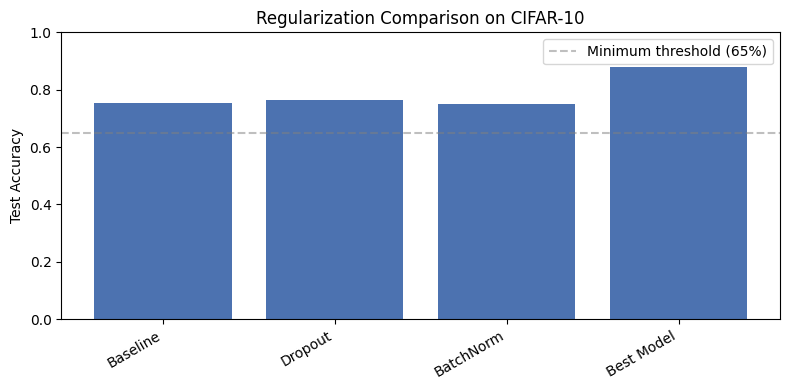

           AUTO-GRADE REPORT
  Baseline            : 75.3%  (>= 65%)  [PASS]
  Dropout             : 76.6%  (>= 65%)  [PASS]
  BatchNorm           : 75.0%  (>= 70%)  [PASS]
  Best Model          : 88.0%  (>= 70%)  [PASS]
---------------------------------------------
  Best Model Accuracy : 88.0%
  Grade               : A+


In [24]:
# Final evaluation on the TEST set (only done here, after all tuning is complete)
#최종 성적비교(baseline, dropout, batchNorm, bestmodel)
print('Final Test Set Evaluation:')
print('=' * 40)
results = {}
for name, model in [('Baseline', baseline), ('Dropout', dropout_model),
                     ('BatchNorm', bn_model), ('Best Model', best_model)]:
    _, acc = evaluate(model, testloader)
    results[name] = acc
    print(f'  {name:15s}: {acc:.4f}')
print('=' * 40)

# --- Bar Chart ---
plt.figure(figsize=(8, 4))
colors = ['#4C72B0' if v >= 0.65 else '#C44E52' for v in results.values()]
plt.bar(results.keys(), results.values(), color=colors)
plt.ylabel('Test Accuracy')
plt.title('Regularization Comparison on CIFAR-10')
plt.ylim(0, 1)
plt.axhline(y=0.65, color='gray', linestyle='--', alpha=0.5, label='Minimum threshold (65%)')
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# --- Auto-Grading ---
def compute_grade(best_acc):
    if best_acc >= 0.85: return 'A+'
    elif best_acc >= 0.82: return 'A'
    elif best_acc >= 0.79: return 'B+'
    elif best_acc >= 0.76: return 'B'
    elif best_acc >= 0.70: return 'C'
    else: return 'F'

thresholds = {
    'Baseline': 0.65,
    'Dropout': 0.65,
    'BatchNorm': 0.70,
    'Best Model': 0.70,
}

print('=' * 45)
print('           AUTO-GRADE REPORT')
print('=' * 45)
all_pass = True
for task, threshold in thresholds.items():
    acc = results[task]
    passed = acc >= threshold
    status = 'PASS' if passed else 'FAIL'
    if not passed:
        all_pass = False
    print(f'  {task:20s}: {acc:.1%}  (>= {threshold:.0%})  [{status}]')

best = results['Best Model']
grade = compute_grade(best)
print('-' * 45)
print(f'  Best Model Accuracy : {best:.1%}')
print(f'  Grade               : {grade}')
if not all_pass:
    print('  WARNING: Some tasks below minimum threshold!')
print('=' * 45)

### 6-2. Training Curves

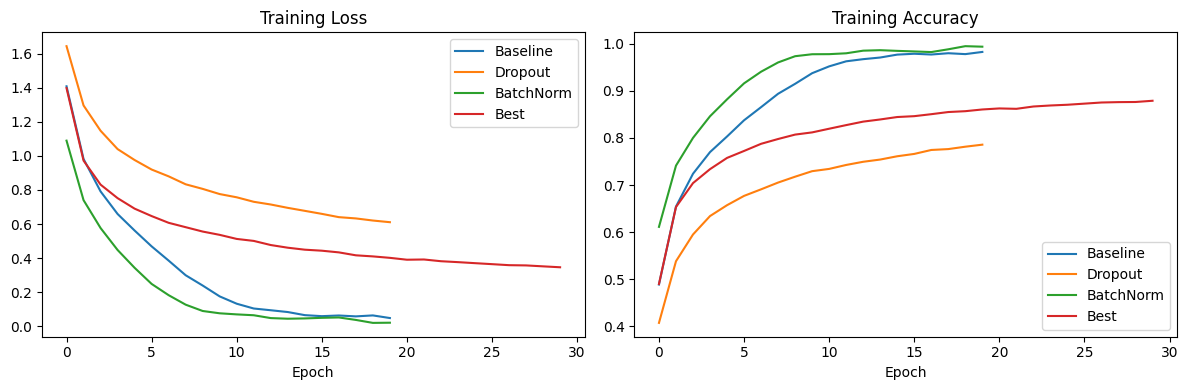

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for name, hist in [('Baseline', hist_baseline), ('Dropout', hist_dropout),
                    ('BatchNorm', hist_bn), ('Best', hist_best)]:
    ax1.plot(hist['loss'], label=name)
    ax2.plot(hist['acc'], label=name)

ax1.set_title('Training Loss'); ax1.set_xlabel('Epoch'); ax1.legend()
ax2.set_title('Training Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout()
plt.show()

### 6-3. Questions (Answer in text cells below)

1. Which regularization technique (Dropout vs BatchNorm) gave the bigger improvement over the baseline? Why do you think so?
2. Compare the training curves (loss & accuracy) of the baseline vs. your best model. What differences do you observe regarding overfitting?
3. Based on your Grad-CAM visualizations from Task 5, which model (Baseline vs BatchNorm) focuses on more task-relevant image regions? How might this relate to their accuracy difference?

1. 본 실험에서는 Dropout이 BatchNorm보다 Baseline 대비 더 큰 성능 향상을 보였습니다. Dropout 모델의 validation accuracy는 76.6%로 BatchNorm 모델(75%)보다 높았으며, BatchNorm은 오히려 Baseline(75.3%)보다도 낮은 성능을 보였습니다.
이러한 결과는 Dropout이 학습 과정에서 일부 뉴런을 무작위로 비활성화함으로써 overfitting을 효과적으로 방지하고, 일반화 성능을 향상시켰기 때문으로 해석할 수 있습니다. 반면 BatchNorm은 입력 분포를 정규화하여 학습을 안정화하고 수렴 속도를 높이는 역할을 하지만, 항상 일반화 성능 향상으로 이어지는 것은 아닙니다.
또한 BatchNorm의 효과는 모델 구조, 학습률, 데이터셋 등의 조건에 따라 달라질 수 있기 때문에, 본 실험 환경에서는 기대만큼의 성능 향상을 보이지 않았을 가능성이 있습니다.

2. Baseline 모델은 학습 초기에 Loss가 급격히 떨어지면서 Train Accuracy 만 높고(거의 100%) Test Accuracy는 낮은(75%) Overfitting 현상이 뚜렷했습니다. 반면 Best Model은 Data Augmentation과 Dropout 덕분에 학습 속도는 다소 느리더라도, 실제 test에서는 제일 좋은 성능을 보였습니다(train 약 88%, 실제 88%). best model에 스케줄링을 추가했었는데, 스케줄링도 성능에 기여한 것 같습니다.

3. Baseline은 배경에 하이라이트가 분산되는 경우가 많았습니다. 반면 BatchNorm 모델은 사물의 핵심 부위(다리, 몸통)에 빨간색이 집중되었습니다. 이는 모델이 분류에 실질적으로 필요한 특징을 정확히 파악하고 있음을 의미하며, 이것이 곧 높은 Accuracy로 연결되었다고 분석됩니다.